# Modelos Predictivos.
### Objetivos

1. Hacer predicciones simples
2. Evaluar modelos básicos

## Descomponer la Serie Temporal

In [1]:
import math
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error


#### Descomponer en tendencia, estacionalidad y residuo

In [2]:
df = pd.read_csv("data/visitas_proc_1.csv", index_col="fecha", parse_dates= True)
df

,visitas,anio,mes,dia_semana,numero_semana
fecha,,,,,
2022-01-01,109,2022,1,Saturday,1
2022-01-02,137,2022,1,Sunday,1
2022-01-03,164,2022,1,Monday,2
2022-01-04,156,2022,1,Tuesday,2
2022-01-05,78,2022,1,Wednesday,2
...,...,...,...,...,...
2023-12-27,268,2023,12,Wednesday,53
2023-12-28,246,2023,12,Thursday,53
2023-12-29,264,2023,12,Friday,53


Descomposición explicada:
1. ORIGINAL: Los datos tal cual
2. TENDENCIA: La dirección general (creciente/decreciente)
3. ESTACIONALIDAD: Patrones que se repiten cada período
4. RESIDUO: Fluctuaciones no explicadas por tendencia ni estacionalidad

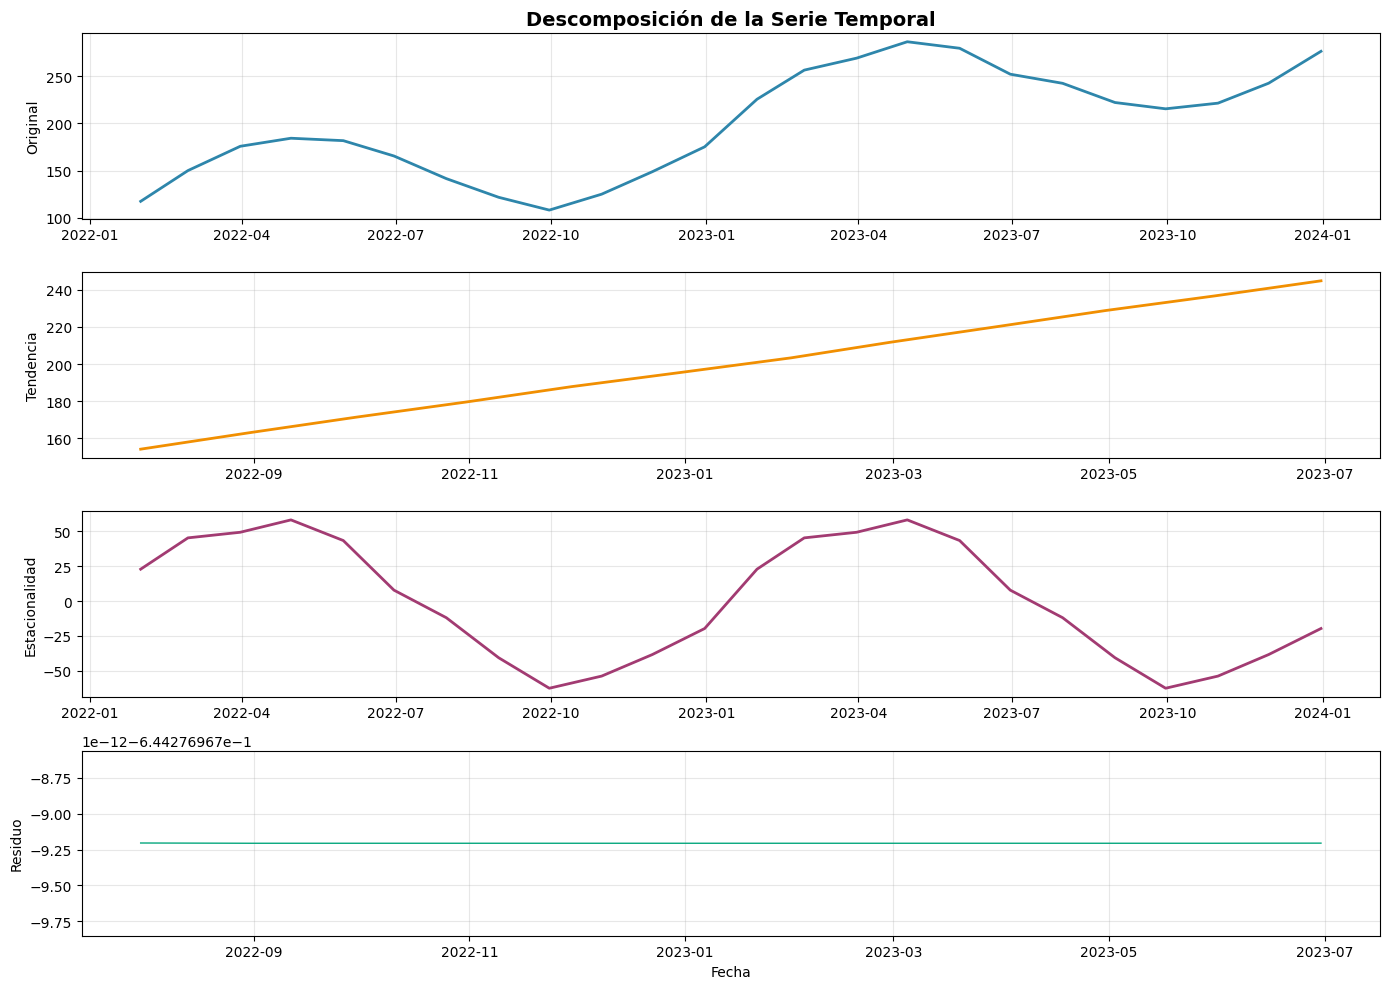

In [3]:
# Usar datos mensuales para mayor claridad
df_mensual_decomp = df['visitas'].resample('ME').mean()

# Descomponer
descomposición = seasonal_decompose(df_mensual_decomp, model='additive', period=12)

# Visualizar
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Original
axes[0].plot(df_mensual_decomp.index, df_mensual_decomp.values, color='#2E86AB', linewidth=2)
axes[0].set_ylabel('Original')
axes[0].set_title('Descomposición de la Serie Temporal', fontweight='bold', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Tendencia
axes[1].plot(descomposición.trend.index, descomposición.trend.values, color='#F18F01', linewidth=2)
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

# Estacionalidad
axes[2].plot(descomposición.seasonal.index, descomposición.seasonal.values, color='#A23B72', linewidth=2)
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

# Residuo
axes[3].plot(descomposición.resid.index, descomposición.resid.values, color='#06A77D', linewidth=1)
axes[3].set_ylabel('Residuo')
axes[3].set_xlabel('Fecha')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Predicción Simple (60 minutos)

### Preparar datos para entrenar un modelo

In [4]:
df.head()

,visitas,anio,mes,dia_semana,numero_semana
fecha,,,,,
2022-01-01,109,2022,1,Saturday,1
2022-01-02,137,2022,1,Sunday,1
2022-01-03,164,2022,1,Monday,2
2022-01-04,156,2022,1,Tuesday,2
2022-01-05,78,2022,1,Wednesday,2


In [5]:
df_modelo = df.copy()

# Features
df_modelo['mes'] = df_modelo.index.month
df_modelo['día_semana'] = df_modelo.index.dayofweek
df_modelo['es_fin_semana'] = (df_modelo['día_semana'] >= 5).astype(int)
df_modelo['visitas_lag_1'] = df_modelo['visitas'].shift(1)
df_modelo['visitas_lag_7'] = df_modelo['visitas'].shift(7)
df_modelo['promedio_móvil_7'] = df_modelo['visitas'].rolling(window=7).mean()

# Target
df_modelo['visitas_mañana'] = df_modelo['visitas'].shift(-1)

# Eliminar filas con NaN
df_modelo_limpio = df_modelo.dropna()


In [11]:
df_modelo_limpio.head()

,visitas,anio,mes,dia_semana,numero_semana,día_semana,es_fin_semana,visitas_lag_1,visitas_lag_7,promedio_móvil_7,visitas_mañana
fecha,,,,,,,,,,,
2022-01-08,124,2022,1,Saturday,2,5,1,100.0,109.0,116.000000,140.0
2022-01-09,140,2022,1,Sunday,2,6,1,124.0,137.0,116.428571,171.0
2022-01-10,171,2022,1,Monday,3,0,0,140.0,164.0,117.428571,125.0
2022-01-11,125,2022,1,Tuesday,3,1,0,171.0,156.0,113.000000,83.0
2022-01-12,83,2022,1,Wednesday,3,2,0,125.0,78.0,113.714286,71.0


### Dividir en entrenamiento y prueba

En series temporales, NO debemos mezclar aleatoriamente

Los datos de prueba deben ser POSTERIORES a los de entrenamiento

In [6]:
# 80% para entrenamiento, 20% para prueba
split_idx = int(len(df_modelo_limpio) * 0.8)

X_train = df_modelo_limpio[['mes', 'día_semana', 'es_fin_semana', 'visitas_lag_1', 'visitas_lag_7', 'promedio_móvil_7']].iloc[:split_idx]
y_train = df_modelo_limpio['visitas_mañana'].iloc[:split_idx]

X_test = df_modelo_limpio[['mes', 'día_semana', 'es_fin_semana', 'visitas_lag_1', 'visitas_lag_7', 'promedio_móvil_7']].iloc[split_idx:]
y_test = df_modelo_limpio['visitas_mañana'].iloc[split_idx:]

print(f'Entrenamiento: {len(X_train)} muestras ({X_train.index.min().date()} a {X_train.index.max().date()})')
print(f'Prueba: {len(X_test)} muestras ({X_test.index.min().date()} a {X_test.index.max().date()})')

Entrenamiento: 577 muestras (2022-01-08 a 2023-08-07)
Prueba: 145 muestras (2023-08-08 a 2023-12-30)


### Modelo 1: Predicción Ingenua (baseline)

Predecir: el valor de hoy será igual al de hace 1 día

In [7]:
# Las predicciones ingenuas
y_pred_naive = df_modelo_limpio['visitas_lag_1'].iloc[split_idx:]

# Calcular error
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = math.sqrt(mean_squared_error(y_test, y_pred_naive))

print(f'MAE (Error Promedio): {mae_naive:.2f} visitas')
print(f'RMSE (Raíz del Error Cuadrático): {rmse_naive:.2f} visitas')

MAE (Error Promedio): 51.63 visitas
RMSE (Raíz del Error Cuadrático): 60.89 visitas


### Modelo 2: Regresión Lineal

Buscar relación lineal entre features y visitas

In [8]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

y_pred_lr = modelo_lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = math.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f'MAE: {mae_lr:.2f} visitas')
print(f'RMSE: {rmse_lr:.2f} visitas')

print(f'\nImportancia de features:')
for col, coef in zip(X_train.columns, modelo_lr.coef_):
    print(f'  {col}: {coef:.4f}')

MAE: 21.90 visitas
RMSE: 27.82 visitas

Importancia de features:
  mes: -0.3830
  día_semana: -3.5245
  es_fin_semana: 54.1335
  visitas_lag_1: -0.2857
  visitas_lag_7: 0.3918
  promedio_móvil_7: 0.8707


### Modelo 3: Random Forest

In [9]:
X_train

,mes,día_semana,es_fin_semana,visitas_lag_1,visitas_lag_7,promedio_móvil_7
fecha,,,,,,
2022-01-08,1,5,1,100.0,109.0,116.000000
2022-01-09,1,6,1,124.0,137.0,116.428571
2022-01-10,1,0,0,140.0,164.0,117.428571
2022-01-11,1,1,0,171.0,156.0,113.000000
2022-01-12,1,2,0,125.0,78.0,113.714286
...,...,...,...,...,...,...
2023-08-03,8,3,0,177.0,190.0,226.857143
2023-08-04,8,4,0,202.0,188.0,227.714286
2023-08-05,8,5,1,194.0,247.0,223.571429


In [10]:
y_train

fecha
2022-01-08    140.0
2022-01-09    171.0
2022-01-10    125.0
2022-01-11     83.0
2022-01-12     71.0
              ...  
2023-08-03    194.0
2023-08-04    218.0
2023-08-05    277.0
2023-08-06    319.0
2023-08-07    250.0
Name: visitas_mañana, Length: 577, dtype: float64

In [12]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = math.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f'MAE: {mae_rf:.2f} visitas')
print(f'RMSE: {rmse_rf:.2f} visitas')

# Importancia de features
print(f'\nImportancia de features:')
for col, importance in zip(X_train.columns, modelo_rf.feature_importances_):
    print(f'  {col}: {importance:.4f}')

MAE: 19.25 visitas
RMSE: 24.07 visitas

Importancia de features:
  mes: 0.0110
  día_semana: 0.1485
  es_fin_semana: 0.0497
  visitas_lag_1: 0.0287
  visitas_lag_7: 0.2075
  promedio_móvil_7: 0.5546


#### Comparar modelos

In [13]:

print('\n=== COMPARACIÓN DE MODELOS ===')
print(f"\n{'Modelo':<20} {'MAE':<12} {'RMSE':<12}")
print('-' * 44)
print(f"{'Naive (lag-1)':<20} {mae_naive:<12.2f} {rmse_naive:<12.2f}")
print(f"{'Regresión Lineal':<20} {mae_lr:<12.2f} {rmse_lr:<12.2f}")
print(f"{'Random Forest':<20} {mae_rf:<12.2f} {rmse_rf:<12.2f}")

# Mejor modelo
errores = {'Naive': mae_naive, 'Lineal': mae_lr, 'RF': mae_rf}
mejor = min(errores, key=errores.get)
print(f'\nMejor modelo: {mejor}')


=== COMPARACIÓN DE MODELOS ===

Modelo               MAE          RMSE        
--------------------------------------------
Naive (lag-1)        51.63        60.89       
Regresión Lineal     21.90        27.82       
Random Forest        19.25        24.07       

Mejor modelo: RF


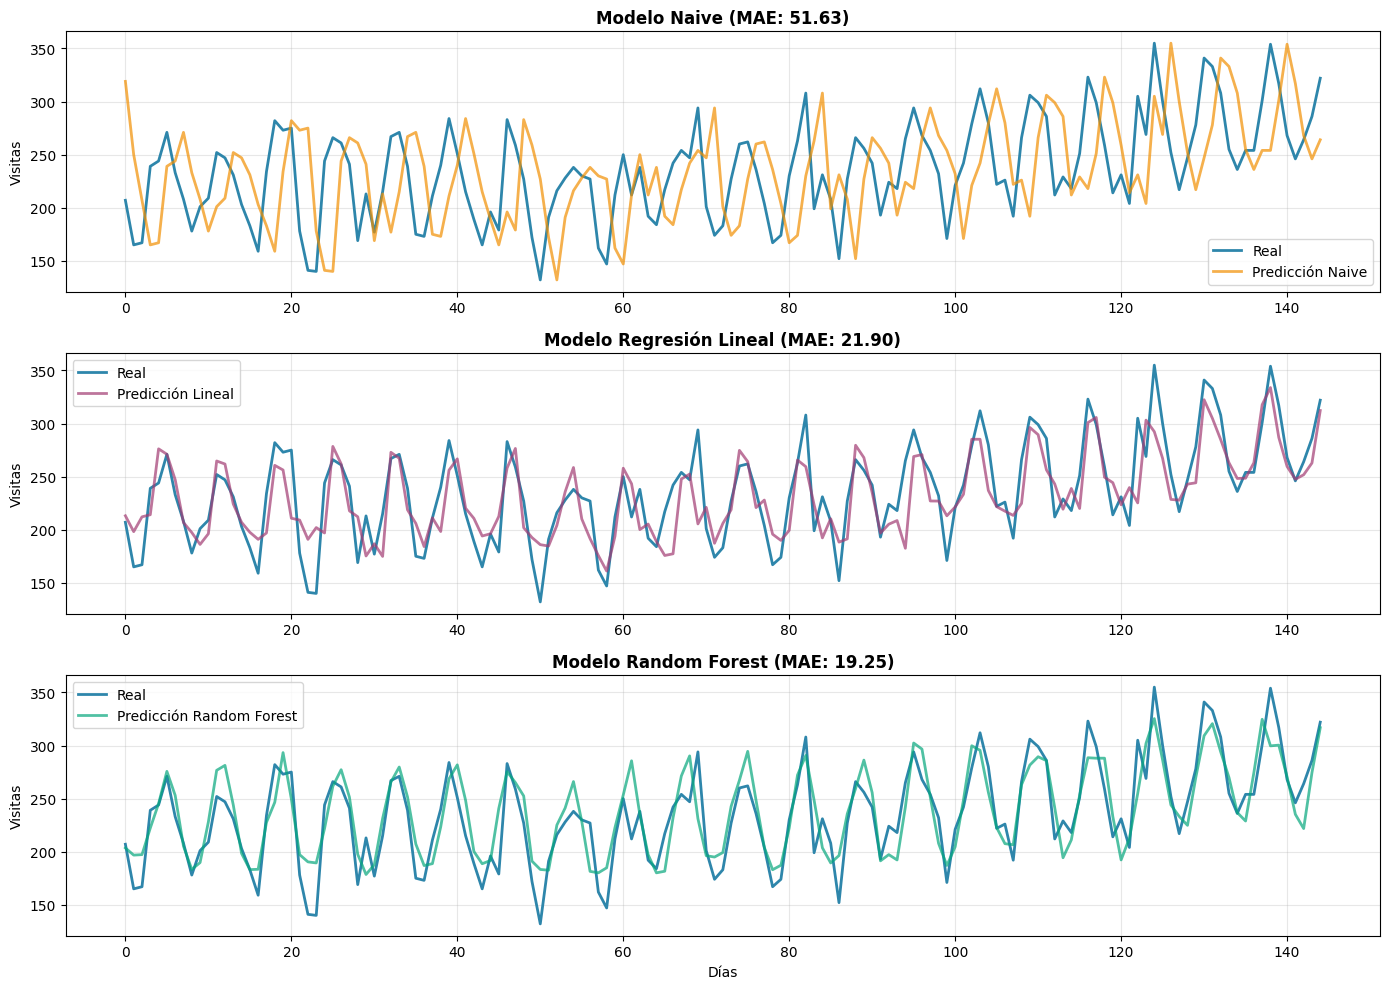

In [14]:
# Visualizar predicciones vs real
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Eje X
x_axis = range(len(y_test))

# Naive
axes[0].plot(x_axis, y_test.values, label='Real', linewidth=2, color='#2E86AB')
axes[0].plot(x_axis, y_pred_naive.values, label='Predicción Naive', alpha=0.7, linewidth=2, color='#F18F01')
axes[0].set_title(f'Modelo Naive (MAE: {mae_naive:.2f})', fontweight='bold')
axes[0].set_ylabel('Visitas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lineal
axes[1].plot(x_axis, y_test.values, label='Real', linewidth=2, color='#2E86AB')
axes[1].plot(x_axis, y_pred_lr, label='Predicción Lineal', alpha=0.7, linewidth=2, color='#A23B72')
axes[1].set_title(f'Modelo Regresión Lineal (MAE: {mae_lr:.2f})', fontweight='bold')
axes[1].set_ylabel('Visitas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# RF
axes[2].plot(x_axis, y_test.values, label='Real', linewidth=2, color='#2E86AB')
axes[2].plot(x_axis, y_pred_rf, label='Predicción Random Forest', alpha=0.7, linewidth=2, color='#06A77D')
axes[2].set_title(f'Modelo Random Forest (MAE: {mae_rf:.2f})', fontweight='bold')
axes[2].set_xlabel('Días')
axes[2].set_ylabel('Visitas')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Predicción Futura

Creamos 30 fechas nuevas y creamos una predicción en cuanto a los valores de la semana anterior.

In [15]:
# Empezar desde el último día del dataset
ultima_fecha = df_modelo_limpio.index[-1]

# Crear 30 predicciones futuras
predicciones_futuro = []
features_futuro = []

# Usar los últimos datos como punto de partida
último_registro = df_modelo_limpio.iloc[-1]

for i in range(1, 31):  # Próximos 30 días
    # Fecha
    fecha_futura = ultima_fecha + pd.Timedelta(days=i)
    
    # Crear features para el día futuro
    mes = fecha_futura.month
    dia_semana = fecha_futura.dayofweek
    es_fin_semana = 1 if dia_semana >= 5 else 0
    visitas_lag_1 = predicciones_futuro[-1] if predicciones_futuro else último_registro['visitas']
    
    # Para lag_7 y promedio_móvil_7, usaremos los últimos valores reales
    if i <= 7:
        visitas_lag_7 = df_modelo_limpio['visitas'].iloc[-(8-i)]
        promedio_móvil_7 = df_modelo_limpio['promedio_móvil_7'].iloc[-1]
    else:
        visitas_lag_7 = predicciones_futuro[i-8]
        promedio_móvil_7 = np.mean(predicciones_futuro[i-7:i])
    
    # Hacer predicción
    X_futuro = pd.DataFrame({
        'mes': [mes],
        'día_semana': [dia_semana],
        'es_fin_semana': [es_fin_semana],
        'visitas_lag_1': [visitas_lag_1],
        'visitas_lag_7': [visitas_lag_7],
        'promedio_móvil_7': [promedio_móvil_7]
    })
    
    pred = modelo_rf.predict(X_futuro)[0]
    predicciones_futuro.append(pred)


In [16]:
fechas_futuro = [ultima_fecha + pd.Timedelta(days=i) for i in range(1, 31)]
df_predicciones = pd.DataFrame({
    'fecha': fechas_futuro,
    'predicción': predicciones_futuro
})
df_predicciones['predicción'] = df_predicciones['predicción'].astype(int)

df_predicciones

,fecha,predicción
0,2023-12-31,317
1,2024-01-01,295
2,2024-01-02,263
3,2024-01-03,230
4,2024-01-04,235
5,2024-01-05,283
6,2024-01-06,319
7,2024-01-07,334
8,2024-01-08,300
9,2024-01-09,251


#### Visualizar: datos históricos + predicciones futuras

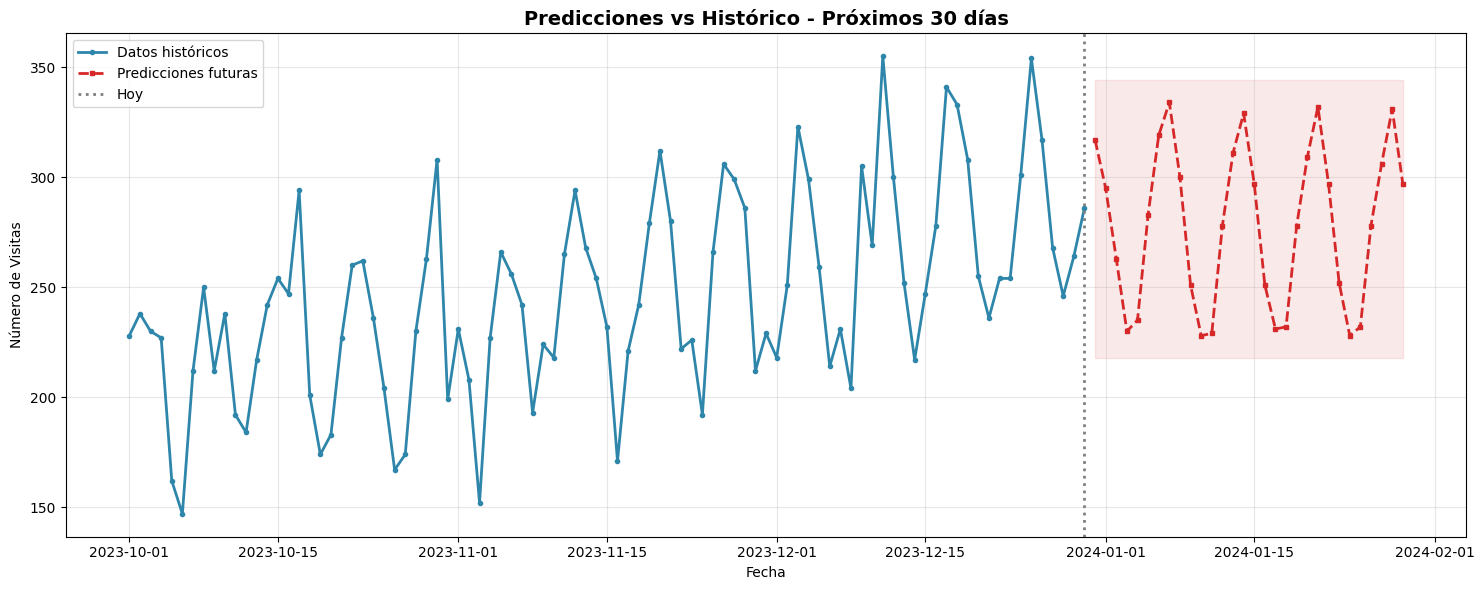


Resumen de predicciones:
Promedio: 278 visitas/día
Mínimo: 228 visitas
Máximo: 334 visitas


In [17]:

fig, ax = plt.subplots(figsize=(15, 6))

# Datos históricos
rango_histórico = df_modelo_limpio['2023-10':].index
ax.plot(rango_histórico, df_modelo_limpio['visitas'].loc[rango_histórico], 
        label='Datos históricos', linewidth=2, color='#2E86AB', marker='o', markersize=3)

# Predicciones futuras
ax.plot(df_predicciones['fecha'], df_predicciones['predicción'], 
        label='Predicciones futuras', linewidth=2, color='#D62828', linestyle='--', marker='s', markersize=3)

# Línea vertical separando presente y futuro
ax.axvline(x=ultima_fecha, color='gray', linestyle=':', linewidth=2, label='Hoy')

# Llenar área de predicciones
ax.fill_between(df_predicciones['fecha'], 
                 df_predicciones['predicción'].min() - 10,
                 df_predicciones['predicción'].max() + 10,
                 alpha=0.1, color='#D62828')

ax.set_title('Predicciones vs Histórico - Próximos 30 días', fontweight='bold', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de Visitas')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nResumen de predicciones:')
print(f'Promedio: {df_predicciones["predicción"].mean():.0f} visitas/día')
print(f'Mínimo: {df_predicciones["predicción"].min():.0f} visitas')
print(f'Máximo: {df_predicciones["predicción"].max():.0f} visitas')

## Métricas de Evaluación Detalladas

### # Análisis detallado del error

In [47]:
# Calcular residuos (diferencia entre predicción y real)
residuos = y_test.values - y_pred_rf

# Estadísticas de los residuos
print(f'\nResíduos (Errores):')
print(f'Media: {residuos.mean():.2f} (debería ser ~0)')
print(f'Desv. Estándar: {residuos.std():.2f}')
print(f'Mínimo: {residuos.min():.2f}')
print(f'Máximo: {residuos.max():.2f}')

# Percentiles
print(f'\nPercentiles del error absoluto:')
errores_abs = np.abs(residuos)
print(f'50% (Mediana): {np.percentile(errores_abs, 50):.2f}')
print(f'75%: {np.percentile(errores_abs, 75):.2f}')
print(f'90%: {np.percentile(errores_abs, 90):.2f}')
print(f'95%: {np.percentile(errores_abs, 95):.2f}')


Resíduos (Errores):
Media: -2.89 (debería ser ~0)
Desv. Estándar: 23.90
Mínimo: -73.61
Máximo: 62.96

Percentiles del error absoluto:
50% (Mediana): 16.29
75%: 27.38
90%: 36.92
95%: 49.41


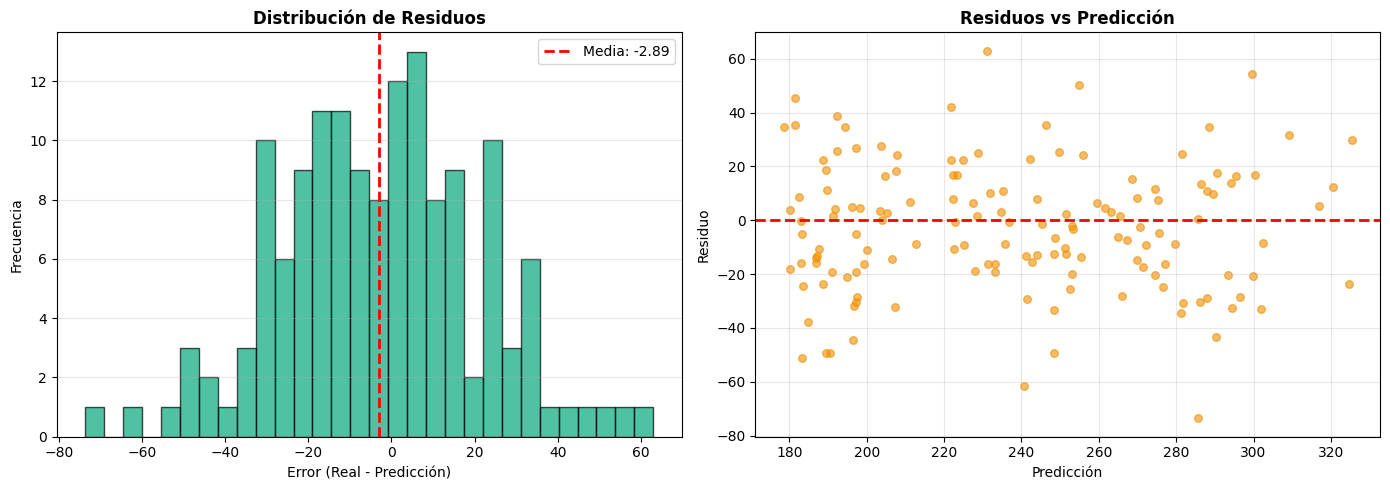

In [48]:
# Visualizar distribución del error
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de residuos
axes[0].hist(residuos, bins=30, color='#06A77D', edgecolor='black', alpha=0.7)
axes[0].axvline(residuos.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {residuos.mean():.2f}')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Error (Real - Predicción)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Gráfico de residuos vs predicción
axes[1].scatter(y_pred_rf, residuos, alpha=0.6, color='#F18F01', s=30)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuos vs Predicción', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Residuo')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Error porcentual

In [50]:
mape = np.mean(np.abs((y_test.values - y_pred_rf) / y_test.values)) * 100

print(f'MAPE (Error Porcentual Promedio): {mape:.2f}%')
print(f'\nInterpretación:')
if mape < 5:
    print(' Excelente (< 5%)')
elif mape < 10:
    print(' Muy bueno (< 10%)')
elif mape < 20:
    print(' Bueno (< 20%)')
else:
    print(' Puede mejorar (> 20%)')

MAPE (Error Porcentual Promedio): 8.74%

Interpretación:
 Muy bueno (< 10%)
